In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("Insight-Financial-Transaction-2024H1.csv")

In [3]:
df.head()

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_GENERATION,CARD_HOLDER_TOTAL_TRANSACTION_COUNT,CARD_HOLDER_TOTAL_SPEND,CARD_HOLDER_AVERAGE_LTM_SPEND,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION
0,A6184793,C7717436,T8535582,0.99,2024-03-13 06:46:55.000,Spend,OH,EUCLID,OH,WESTLAKE,...,Gen Z,443,8452.70,511.77,26.25,29,Card Not Present,112,WENDYS,0
1,A2296562,C5518346,T2383075,22.76,2024-05-16 20:34:18.000,Spend,MI,FORT GRATIOT,MI,FORT GRATIOT,...,Millennial,3382,115654.41,NaN,NaN,87,Card Present,214,JIMMY JOHNS GOURMET SANDWICHES,2
2,A5523719,C7179772,T7494465,8.84,2024-04-25 17:09:37.000,Spend,OH,TOLEDO,OH,TOLEDO,...,Gen Z,1999,48756.32,2400.99,100.33,25,Card Present,58,SUBWAY,0
3,A7905524,C1779514,T5897261,8.78,2024-05-26 13:50:06.000,Spend,IN,LAFAYETTE,IN,LAFAYETTE,...,Gen Z,449,10444.67,NaN,NaN,26,Card Not Present,37,MCDONALDS,0
4,A7846687,C8240547,T2709494,18.01,2024-05-05 19:54:35.000,Spend,MN,DELANO,MN,DELANO,...,Baby Boomer,551,16220.59,1513.71,51.27,10,Card Present,522,CULVERS,0


In [4]:
df.isnull().sum()

ACCOUNT_ID                                    132703
CARD_ID                                            0
TRANSACTION_ID                                     0
GROSS_TRANSACTION_AMOUNT                           0
TRANSACTION_DATE                                   0
TRANSACTION_TYPE                                   1
TRANSACTION_STATE                             121664
TRANSACTION_CITY                              143825
MERCHANT_STATE                                583358
MERCHANT_CITY                                 702539
MERCHANT_CATEGORY_LEVEL_1                    1293772
MERCHANT_CATEGORY_LEVEL_2                    1293772
MERCHANT_CATEGORY_LEVEL_3                    1293982
TRANSACTION_DESCRIPTION                         5463
CARD_TYPE                                          0
CARD_HOLDER_STATE                              19430
CARD_HOLDER_CITY                               19430
CARD_HOLDER_GENERATION                         57808
CARD_HOLDER_TOTAL_TRANSACTION_COUNT           

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4777635 entries, 0 to 4777634
Data columns (total 27 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   ACCOUNT_ID                                 str    
 1   CARD_ID                                    str    
 2   TRANSACTION_ID                             str    
 3   GROSS_TRANSACTION_AMOUNT                   float64
 4   TRANSACTION_DATE                           str    
 5   TRANSACTION_TYPE                           str    
 6   TRANSACTION_STATE                          str    
 7   TRANSACTION_CITY                           str    
 8   MERCHANT_STATE                             str    
 9   MERCHANT_CITY                              str    
 10  MERCHANT_CATEGORY_LEVEL_1                  str    
 11  MERCHANT_CATEGORY_LEVEL_2                  str    
 12  MERCHANT_CATEGORY_LEVEL_3                  str    
 13  TRANSACTION_DESCRIPTION                    str    
 1

In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. 객체 생성
le = LabelEncoder()

# 2. 데이터 학습 및 변환 (df의 'CARD_HOLDER_STATE' 컬럼 기준)
df['STATE_encoded'] = le.fit_transform(df['CARD_HOLDER_STATE'])

# 결과 확인
print(df[['CARD_HOLDER_STATE', 'STATE_encoded']].head())

  CARD_HOLDER_STATE  STATE_encoded
0                OH             41
1                MI             27
2                OH             41
3                IN             20
4                MN             28


In [7]:
df['CARD_HOLDER_STATE'].unique()

<StringArray>
['OH', 'MI', 'IN', 'MN', 'WI', 'TX', 'NC', 'KY', 'OK', 'FL', 'LA', 'VA', 'MA',
 'IL', 'MS', 'SC', 'CO', 'UT', 'TN', 'NE', 'MO', 'CA', 'NM', 'GA', 'AL', 'ND',
 'AZ', 'PA', 'OR', 'DE', 'IA', 'ID', 'WA', 'NY',  nan, 'PR', 'NV', 'KS', 'AR',
 'HI', 'CT', 'WV', 'RI', 'MD', 'ME', 'SD', 'DC', 'VT', 'NJ', 'MT', 'NH', 'AK',
 'WY', 'GU', 'AE', 'AP', 'MP', 'VI', 'AA', 'AS']
Length: 60, dtype: str

In [8]:
# 1. 모든 상관계수 행렬 계산
correlation_matrix = df.corr(numeric_only=True)

# 2. 특정 컬럼('target_column')만 선택하고 내림차순 정렬
CARD_HOLDER_STATE_corr = correlation_matrix['STATE_encoded'].sort_values(ascending=False)

print(CARD_HOLDER_STATE_corr)

STATE_encoded                                1.000000
CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT    0.040025
CARD_HOLDER_AVERAGE_LTM_SPEND                0.039944
CARD_HOLDER_TOTAL_TRANSACTION_COUNT          0.036626
CARD_HOLDER_TOTAL_SPEND                      0.036606
SHOPPER_CLASSIFICATION                       0.012881
MERCHANT_ID                                  0.011250
CARD_HOLDER_VINTAGE                          0.007347
GROSS_TRANSACTION_AMOUNT                    -0.014392
Name: STATE_encoded, dtype: float64


In [9]:
import pandas as pd

# 확인할 컬럼 리스트
target_cols = ['CARD_HOLDER_STATE', 'CARD_HOLDER_CITY', 'CARD_HOLDER_GENERATION']

# 각 고객별로 '전체 행 수'와 '값이 있는 행 수'를 비교
for col in target_cols:
    group_info = df.groupby('ACCOUNT_ID')[col].agg(['size', 'count'])
    
    # 혼재된 경우: 전체 행(size)은 있는데, 실제 값(count)은 그보다 적고, 0보다는 큰 경우
    mixed_customers = group_info[(group_info['count'] < group_info['size']) & (group_info['count'] > 0)]
    
    print(f"--- [{col}] 확인 결과 ---")
    print(f"결측치가 혼재된 고객 수: {len(mixed_customers)}명")
    if len(mixed_customers) > 0:
        print(f"예시 ACCOUNT_ID: {mixed_customers.index[:5].tolist()}")
    print("\n")

--- [CARD_HOLDER_STATE] 확인 결과 ---
결측치가 혼재된 고객 수: 3373명
예시 ACCOUNT_ID: ['A1001745', 'A1021455', 'A1022642', 'A1024730', 'A1035805']


--- [CARD_HOLDER_CITY] 확인 결과 ---
결측치가 혼재된 고객 수: 3373명
예시 ACCOUNT_ID: ['A1001745', 'A1021455', 'A1022642', 'A1024730', 'A1035805']


--- [CARD_HOLDER_GENERATION] 확인 결과 ---
결측치가 혼재된 고객 수: 0명




In [4]:
pd.set_option('display.max_columns', None)

In [11]:
df[df['ACCOUNT_ID']=='A1001745']

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,MERCHANT_CATEGORY_LEVEL_1,MERCHANT_CATEGORY_LEVEL_2,MERCHANT_CATEGORY_LEVEL_3,TRANSACTION_DESCRIPTION,CARD_TYPE,CARD_HOLDER_STATE,CARD_HOLDER_CITY,CARD_HOLDER_GENERATION,CARD_HOLDER_TOTAL_TRANSACTION_COUNT,CARD_HOLDER_TOTAL_SPEND,CARD_HOLDER_AVERAGE_LTM_SPEND,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,STATE_encoded
4069321,A1001745,C1528114,T5375789,30.72,2024-02-21 22:43:11.000,Spend,TX,PASADENA,TX,PASADENA,Restaurants and Food Services,QSR,QSR Chicken,CHICK-FIL-A #01832,Debit,NaN,NaN,Gen X,719,30774.81,2593.42,60.92,11,Card Present,155,CHICK-FIL-A,0,59
4530795,A1001745,C1528114,T7701342,4.08,2024-04-05 13:51:22.000,Spend,NaN,NaN,NaN,NaN,Restaurants and Food Services,QSR,QSR Burgers,MCDONALD'S F10948,Debit,TX,SEABROOK,Gen X,719,30774.81,2593.42,60.92,11,Card Present,37,MCDONALDS,0,50


In [5]:
import pandas as pd

# 1. 채워넣을 대상 컬럼 설정
fill_cols = ['CARD_HOLDER_STATE', 'CARD_HOLDER_CITY']

print("거주지 결측치 복구 시작 (고속 매핑 방식)...")

for col in fill_cols:
    # 2. 각 고객(ACCOUNT_ID)별로 해당 컬럼의 최빈값(가장 많이 등장한 값) 하나를 추출합니다.
    # dropna=True로 설정하여 결측치는 제외하고 실제 값이 있는 것들 중에서만 뽑습니다.
    customer_home_map = df.dropna(subset=[col]).groupby('ACCOUNT_ID')[col].agg(lambda x: x.mode().iat[0])
    
    # 3. 원본 데이터에서 해당 컬럼이 비어있는(isnull) 행만 골라내어 
    # 위에서 만든 '고객별 거주지 사전'을 이용해 값을 채워넣습니다.
    df[col] = df[col].fillna(df['ACCOUNT_ID'].map(customer_home_map))

print("복구가 완료되었습니다!")

# 확인: 아까 봤던 샘플 ID로 결과 확인
# print(df[df['ACCOUNT_ID'] == 'A1001745'][['ACCOUNT_ID', 'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY']])

거주지 결측치 복구 시작 (고속 매핑 방식)...
복구가 완료되었습니다!


In [6]:
df.isnull().sum()

ACCOUNT_ID                                    132703
CARD_ID                                            0
TRANSACTION_ID                                     0
GROSS_TRANSACTION_AMOUNT                           0
TRANSACTION_DATE                                   0
TRANSACTION_TYPE                                   1
TRANSACTION_STATE                             121664
TRANSACTION_CITY                              143825
MERCHANT_STATE                                583358
MERCHANT_CITY                                 702539
MERCHANT_CATEGORY_LEVEL_1                    1293772
MERCHANT_CATEGORY_LEVEL_2                    1293772
MERCHANT_CATEGORY_LEVEL_3                    1293982
TRANSACTION_DESCRIPTION                         5463
CARD_TYPE                                          0
CARD_HOLDER_STATE                              15934
CARD_HOLDER_CITY                               15934
CARD_HOLDER_GENERATION                         57808
CARD_HOLDER_TOTAL_TRANSACTION_COUNT           

In [ ]:
df[df['CARD_HOLDER_STATE'].isnull()]

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,MERCHANT_CATEGORY_LEVEL_1,MERCHANT_CATEGORY_LEVEL_2,MERCHANT_CATEGORY_LEVEL_3,TRANSACTION_DESCRIPTION,CARD_TYPE,CARD_HOLDER_STATE,CARD_HOLDER_CITY,CARD_HOLDER_GENERATION,CARD_HOLDER_TOTAL_TRANSACTION_COUNT,CARD_HOLDER_TOTAL_SPEND,CARD_HOLDER_AVERAGE_LTM_SPEND,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,STATE_encoded
139,NaN,C8343496,T1284078,41.71,2024-04-28 00:10:25.000,Spend,NaN,NaN,NaN,NaN,Restaurants and Food Services,Casual Dining,Pizza Restaurants,NJ 732-406-0070 DOMINO S 4973 USDOMINO...,Payroll,NaN,NaN,NaN,337,1.583129e+04,6.405700e+02,12.67,25,Unknown,25,DOMINOS,0,59
271,A9513769,C4096692,T5567341,14.10,2024-01-25 20:43:26.000,Spend,CA,LOS ANGELES,CA,LOS ANGELES,NaN,NaN,NaN,LITTLE CHINA EXPRESS,Debit,NaN,NaN,Gen X,809,3.238281e+04,2.658800e+03,66.00,12,Card Present,0,NO ENTITY,0,59
311,A4485138,C9594137,T2078141,6.70,2024-03-14 23:48:41.000,Spend,NaN,NaN,NaN,NaN,Restaurants and Food Services,QSR,QSR Burgers,WENDY'S 8338,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,112,WENDYS,0,59
800,A8271130,C3574390,T6283185,19.09,2024-02-21 20:17:24.000,Spend,GA,TUCKER,GA,TUCKER,Restaurants and Food Services,Casual Dining,Pizza Restaurants,PAPA JOHNS #1029,Credit,NaN,NaN,Silent,299,2.200202e+04,1.857820e+03,25.08,11,Card Present,442,PAPA JOHNS,0,59
1160,A1364164,C1998610,T2202271,0.02,2024-01-21 20:46:08.000,Other,NaN,NaN,NaN,NaN,Restaurants and Food Services,Casual Dining,Breakfast Restaurants,DUNKIN CARD VERIFICATION,Debit,NaN,NaN,Baby Boomer,627,2.153165e+04,1.780640e+03,51.42,12,Unknown,26,DUNKIN DONUTS,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775473,A2493690,C3294950,T1835854,11.01,2024-04-07 04:06:27.000,Spend,AZ,QUEEN CREEK,AZ,QUEEN CREEK,Restaurants and Food Services,Casual Dining,Asian Restaurants,PANDA EXPRESS,Debit,NaN,NaN,Gen X,436,1.505724e+04,1.170410e+03,34.50,13,Card Present,250,PANDA EXPRESS,0,59
4776153,A1849788,C5506203,T7657218,10.10,2024-02-27 16:39:14.000,Spend,NaN,NaN,WA,SEATTLE,Restaurants and Food Services,QSR,Coffee / Tea,STARBUCKS 800-782-7282,Debit,NaN,NaN,Millennial,448,1.668976e+04,1.408140e+03,37.83,11,Card Not Present,42,STARBUCKS,0,59
4776176,A2624293,C6475299,T1601162,2.68,2024-01-07 13:32:30.000,Spend,MI,TROY,MI,TROY,NaN,NaN,NaN,365 SOS AUTO APRIVA,Debit,NaN,NaN,Gen X,929,2.358065e+04,1.917140e+03,73.58,13,Card Present,0,NO ENTITY,0,59
4776265,A5847609,C6814525,T3681800,15.74,2024-02-26 19:44:50.000,Spend,NC,SYLVA,NC,SYLVA,Restaurants and Food Services,QSR,QSR Chicken,BOJANGLES 722,Debit,NaN,NaN,Millennial,476,1.828386e+04,1.588280e+03,40.42,11,Card Present,468,BOJANGLES FAMOUS CHICKEN N BISCUITS,0,59


In [15]:
# 1. CARD_ID와 ACCOUNT_ID 정보가 모두 있는 데이터만 추출
check_df = df.dropna(subset=['CARD_ID', 'ACCOUNT_ID'])

# 2. CARD_ID 하나당 ACCOUNT_ID가 몇 종류인지 카운트
card_to_acc_counts = check_df.groupby('CARD_ID')['ACCOUNT_ID'].nunique()

# 3. 한 카드에 ID가 2개 이상인 사례 찾기
conflicts = card_to_acc_counts[card_to_acc_counts > 1]

print(f"--- [가설 검증 결과] ---")
if len(conflicts) == 0:
    print("✅ 가설 성립: 모든 CARD_ID는 단 하나의 ACCOUNT_ID에만 귀속됩니다.")
else:
    print(f"⚠️ 가설 위반: {len(conflicts)}개의 카드가 여러 계정에 연결되어 있습니다.")
    print(conflicts.head())

--- [가설 검증 결과] ---
✅ 가설 성립: 모든 CARD_ID는 단 하나의 ACCOUNT_ID에만 귀속됩니다.


In [16]:
# 가설이 성립한다고 가정하고 실행하는 복구 로직
if len(conflicts) == 0:
    # 1. CARD_ID와 ACCOUNT_ID의 매핑 사전(Dictionary) 생성
    # (결측치 없는 데이터에서 카드-계정 쌍을 추출)
    id_mapping = df.dropna(subset=['ACCOUNT_ID']).set_index('CARD_ID')['ACCOUNT_ID'].to_dict()
    
    # 2. ACCOUNT_ID가 NaN인 행들에 대해 CARD_ID를 기준으로 매핑하여 채우기
    null_mask = df['ACCOUNT_ID'].isnull()
    df.loc[null_mask, 'ACCOUNT_ID'] = df.loc[null_mask, 'CARD_ID'].map(id_mapping)
    
    # 3. 결과 확인
    remaining_nulls = df['ACCOUNT_ID'].isnull().sum()
    print(f"\n--- [복구 결과] ---")
    print(f"복구된 ACCOUNT_ID 건수: {(null_mask.sum() - remaining_nulls):,}건")
    print(f"아직 남은 ACCOUNT_ID 결측치: {remaining_nulls:,}건")
else:
    print("\n❗ 데이터 불일치가 발견되어 자동 복구를 중단했습니다. 수동 확인이 필요합니다.")


--- [복구 결과] ---
복구된 ACCOUNT_ID 건수: 0건
아직 남은 ACCOUNT_ID 결측치: 132,703건


In [17]:
import pandas as pd

# 1. ACCOUNT_ID가 결측치인 데이터만 추출
acc_null_df = df[df['ACCOUNT_ID'].isnull()].copy()

# 2. 그중에서 CARD_ID도 결측치인 경우와 아닌 경우 카운트
both_null_count = acc_null_df['CARD_ID'].isnull().sum()
only_acc_null_count = acc_null_df['CARD_ID'].notnull().sum()
total_acc_null = len(acc_null_df)

print(f"--- [식별자 동시 결측 검증] ---")
print(f"1. ACCOUNT_ID와 CARD_ID가 모두 없는 경우: {both_null_count:,}건 ({both_null_count/total_acc_null:.2%})")
print(f"2. ACCOUNT_ID는 없지만 CARD_ID는 있는 경우: {only_acc_null_count:,}건 ({only_acc_null_count/total_acc_null:.2%})")

# 3. 만약 CARD_ID만이라도 있는 데이터가 있다면 샘플 확인
if only_acc_null_count > 0:
    print("\n[ACCOUNT_ID만 없고 CARD_ID는 살아있는 샘플]")
    display(acc_null_df[acc_null_df['CARD_ID'].notnull()][['TRANSACTION_ID', 'CARD_ID', 'GROSS_TRANSACTION_AMOUNT']].head())

--- [식별자 동시 결측 검증] ---
1. ACCOUNT_ID와 CARD_ID가 모두 없는 경우: 0건 (0.00%)
2. ACCOUNT_ID는 없지만 CARD_ID는 있는 경우: 132,703건 (100.00%)

[ACCOUNT_ID만 없고 CARD_ID는 살아있는 샘플]


,TRANSACTION_ID,CARD_ID,GROSS_TRANSACTION_AMOUNT
109,T8130476,C4268416,19.46
139,T1284078,C8343496,41.71
157,T6923302,C6861766,1.10
173,T2705417,C4213356,15.41
244,T1364990,C2950229,1.34


In [18]:
# 1. ACCOUNT_ID가 결측치인 데이터만 추출
acc_null_df = df[df['ACCOUNT_ID'].isnull()].copy()

# 2. CARD_ID별 등장 횟수(중복도) 계산
card_counts = acc_null_df['CARD_ID'].value_counts()

# 3. 결과 출력
print(f"--- [미식별 데이터 내 CARD_ID 중복 검증] ---")
print(f"전체 미식별 거래 건수: {len(acc_null_df):,}건")
print(f"그 안에 포함된 고유 CARD_ID 개수: {len(card_counts):,}개")

# 중복되는 카드가 있는지 확인
duplicated_cards = card_counts[card_counts > 1]
print(f"\n2회 이상 등장한 '중복 카드' 개수: {len(duplicated_cards):,}개")

if len(duplicated_cards) > 0:
    print("\n[가장 많이 등장한 익명 카드 Top 5]")
    print(duplicated_cards.head())

--- [미식별 데이터 내 CARD_ID 중복 검증] ---
전체 미식별 거래 건수: 132,703건
그 안에 포함된 고유 CARD_ID 개수: 106,241개

2회 이상 등장한 '중복 카드' 개수: 20,337개

[가장 많이 등장한 익명 카드 Top 5]
CARD_ID
C2450649    11
C7109293    11
C1447503     9
C5234122     8
C1377504     8
Name: count, dtype: int64


In [19]:
import pandas as pd

print("--- [데이터 모순 검사] 동일 CARD_ID 내 ID 혼재 여부 ---")

# 1. CARD_ID별로 ACCOUNT_ID의 '결측치 개수'와 '정상값 개수'를 동시에 집계
card_id_check = df.groupby('CARD_ID')['ACCOUNT_ID'].agg(
    total_rows='size',         # 전체 거래 건수
    valid_ids='count',         # ACCOUNT_ID가 있는 건수
    null_ids=lambda x: x.isnull().sum()  # ACCOUNT_ID가 NaN인 건수
)

# 2. 혼재된 조건: 정상값도 있고(valid_ids > 0) 결측치도 있는(null_ids > 0) 경우
mixed_cards = card_id_check[(card_id_check['valid_ids'] > 0) & (card_id_check['null_ids'] > 0)]

# 3. 결과 출력
if len(mixed_cards) > 0:
    print(f"✅ 발견! 동일 카드인데 ACCOUNT_ID가 일부만 누락된 사례: {len(mixed_cards):,}건")
    print("\n[혼재된 CARD_ID 샘플]")
    print(mixed_cards.head())
    
    # 예시 확인 (첫 번째 혼재 카드의 실제 데이터 슥 보기)
    sample_card = mixed_cards.index[0]
    print(f"\n[CARD_ID: {sample_card}의 실제 데이터 상태]")
    display(df[df['CARD_ID'] == sample_card][['CARD_ID', 'ACCOUNT_ID', 'TRANSACTION_DATE']].head(10))
else:
    print("❌ 없음: 모든 CARD_ID는 '다 비어있거나' 혹은 '다 채워져 있거나' 둘 중 하나입니다.")

--- [데이터 모순 검사] 동일 CARD_ID 내 ID 혼재 여부 ---
❌ 없음: 모든 CARD_ID는 '다 비어있거나' 혹은 '다 채워져 있거나' 둘 중 하나입니다.


In [28]:
# 1. 모든 열의 고유값(Unique) 개수 계산
unique_counts = df.nunique()

# 2. 내림차순 정렬 (개수가 많은 순서대로)
sorted_unique = unique_counts.sort_values(ascending=False)

print("--- [열별 Unique 값 개수 순위] ---")
print(sorted_unique)

--- [열별 Unique 값 개수 순위] ---
TRANSACTION_ID                               4777635
TRANSACTION_DATE                             3864934
CARD_ID                                      3762929
ACCOUNT_ID                                   3656572
CARD_HOLDER_TOTAL_SPEND                      3315460
TRANSACTION_DESCRIPTION                       693510
CARD_HOLDER_AVERAGE_LTM_SPEND                 676519
CARD_HOLDER_CITY                               15874
CARD_HOLDER_TOTAL_TRANSACTION_COUNT            14978
GROSS_TRANSACTION_AMOUNT                       14578
TRANSACTION_CITY                               14056
CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT      10259
MERCHANT_CITY                                   9864
MERCHANT_ID                                      788
MERCHANT_NAME                                    788
MERCHANT_CATEGORY_LEVEL_3                         98
CARD_HOLDER_VINTAGE                               89
STATE_encoded                                     60
TRANSACTION_STATE 

In [34]:
df1=df.sort_values(by='CARD_HOLDER_TOTAL_SPEND', ascending=False)

In [35]:
df1

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,MERCHANT_CATEGORY_LEVEL_1,MERCHANT_CATEGORY_LEVEL_2,MERCHANT_CATEGORY_LEVEL_3,TRANSACTION_DESCRIPTION,CARD_TYPE,CARD_HOLDER_STATE,CARD_HOLDER_CITY,CARD_HOLDER_GENERATION,CARD_HOLDER_TOTAL_TRANSACTION_COUNT,CARD_HOLDER_TOTAL_SPEND,CARD_HOLDER_AVERAGE_LTM_SPEND,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,STATE_encoded
2400483,A4485138,C9594137,T9008555,5.53,2024-05-06 23:55:04.000,Spend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123456,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,0,NO ENTITY,0,59
787971,A4485138,C9594137,T3360002,25.42,2024-04-08 23:45:36.000,Spend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123456,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,0,NO ENTITY,0,59
2754079,A4485138,C9594137,T9693682,15.05,2024-02-02 23:45:55.000,Spend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123456,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,0,NO ENTITY,0,59
269660,A4485138,C9594137,T4479257,6.09,2024-05-22 23:46:38.000,Spend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123456,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,0,NO ENTITY,0,59
2862212,A4485138,C9594137,T6766354,7.78,2024-04-19 20:51:46.000,Spend,NaN,NaN,NaN,NaN,Restaurants and Food Services,Casual Dining,American Restaurants,CULVERS OF DELA,Debit,NaN,NaN,NaN,174360569,1.248710e+11,1.699356e+08,1003165.92,71,Unknown,522,CULVERS,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428766,A4516686,C6771182,T2107480,2.51,2024-01-13 09:02:23.000,Spend,IL,BLOOMINGDALE,IL,BLOOMINGDALE,Restaurants and Food Services,Vending & Beverage Retailers,Vending & Beverage Retailers,NaN,Benefit - Health,NaN,NaN,NaN,22,9.978000e+01,9.978000e+01,22.00,0,Card Present,318,USA CANTEEN VENDING,0,59
1412025,A9632125,C3216769,T3544193,1.69,2024-05-07 04:44:12.000,Spend,MI,TROY,MI,TROY,NaN,NaN,NaN,NaN,Benefit - Health,NaN,NaN,NaN,12,8.829000e+01,2.943000e+01,4.00,9,Card Present,0,NO ENTITY,0,59
3010171,A5645628,C3578292,T3171162,1.74,2024-03-24 19:08:43.000,Spend,NY,CORONA,NY,CORONA,Restaurants and Food Services,QSR,QSR Burgers,NaN,Benefit - Health,NaN,NaN,NaN,7,6.002000e+01,2.001000e+01,2.33,7,Card Present,37,MCDONALDS,0,59
4704249,A5093064,C7554077,T1149265,1.95,2024-03-31 01:33:21.000,Spend,AZ,SCOTTSDALE,AZ,SCOTTSDALE,Restaurants and Food Services,QSR,QSR Burgers,NaN,Benefit - Health,NaN,NaN,NaN,2,4.999000e+01,4.999000e+01,2.00,0,Card Present,37,MCDONALDS,0,59


In [ ]:
import pandas as pd

# 1. 거주지 정보와 가맹점 정보가 모두 있는 데이터만 추출 (검증용 세트)
valid_df = df[df['CARD_HOLDER_CITY'].notnull() & df['MERCHANT_CITY'].notnull()].copy()

# 2. 오프라인 결제(실물카드 제시) 데이터만 필터링
# 온라인 결제는 본사 주소로 찍히는 경우가 많아 가설 검증에서 제외해야 합니다.
offline_df = valid_df[valid_df['CARD_PRESENT_INDICATOR'] == 'Card Present'].copy()

# 3. 거주지 주(State)와 가맹점 주(State) 일치 여부 확인
offline_df['is_state_match'] = (offline_df['CARD_HOLDER_STATE'] == offline_df['MERCHANT_STATE'])

# 4. 거주지 도시(City)와 가맹점 도시(City) 일치 여부 확인
offline_df['is_city_match'] = (offline_df['CARD_HOLDER_CITY'] == offline_df['MERCHANT_CITY'])

# 5. 결과 출력
state_match_rate = offline_df['is_state_match'].mean() * 100
city_match_rate = offline_df['is_city_match'].mean() * 100

print(f"--- 가설 검증 결과 (오프라인 결제 기준) ---")
print(f"1. 거주지-가맹점 '주(State)' 일치율: {state_match_rate:.2f}%")
print(f"2. 거주지-가맹점 '도시(City)' 일치율: {city_match_rate:.2f}%")
print(f"분석에 사용된 전체 오프라인 거래 건수: {len(offline_df):,}건")

--- 가설 검증 결과 (오프라인 결제 기준) ---
1. 거주지-가맹점 '주(State)' 일치율: 82.72%
2. 거주지-가맹점 '도시(City)' 일치율: 39.64%
분석에 사용된 전체 오프라인 거래 건수: 3,243,801건


In [36]:
import pandas as pd

# 1. 두 정보가 모두 있는 데이터만 추출 (정확한 계산을 위해 결측치 제외)
valid_state_df = df.dropna(subset=['CARD_HOLDER_STATE', 'MERCHANT_STATE']).copy()

# 2. 거주 주와 결제 주가 동일한지 비교 (True/False 시리즈 생성)
is_same_state = (valid_state_df['CARD_HOLDER_STATE'] == valid_state_df['MERCHANT_STATE'])

# 3. 비율 계산 (True의 평균 * 100)
match_rate = is_same_state.mean() * 100

print(f"--- [거주지 vs 결제지 주(State) 일치 분석] ---")
print(f"분석 대상 거래 건수: {len(valid_state_df):,}건")
print(f"동일 주(State) 내 결제 비율: {match_rate:.2f}%")

# 4. (보너스) 만약 '다른 주'에서 결제된 데이터만 보고 싶다면?
cross_state_tx = valid_state_df[~is_same_state]
print(f"타 주(Cross-state) 결제 건수: {len(cross_state_tx):,}건")

--- [거주지 vs 결제지 주(State) 일치 분석] ---
분석 대상 거래 건수: 4,185,515건
동일 주(State) 내 결제 비율: 79.64%
타 주(Cross-state) 결제 건수: 852,186건


In [ ]:
import pandas as pd

# 1. 시간대 열 생성 (이미 datetime 형식이므로 바로 추출)
df['txn_hour'] = df['TRANSACTION_DATE'].dt.hour

# 2. 필터링 조건 수정
# 'Card Present'가 실물 카드 결제(오프라인)를 의미함
is_offline = (df['CARD_PRESENT_INDICATOR'] == 'Card Present')
has_location = (df['CARD_HOLDER_CITY'].notnull()) & (df['MERCHANT_CITY'].notnull())
is_night = (df['txn_hour'] >= 22) | (df['txn_hour'] <= 6)

# 3. 심야 오프라인 데이터 추출
night_df = df[is_offline & has_location & is_night].copy()

# 4. 결과 출력
if len(night_df) > 0:
    night_df['is_city_match'] = (night_df['CARD_HOLDER_CITY'] == night_df['MERCHANT_CITY'])
    night_match_rate = night_df['is_city_match'].mean() * 100
    
    print(f"--- 심야 시간대(22시~06시) 가설 검증 결과 ---")
    print(f"심야 시간대 일치율: {night_match_rate:.2f}%")
    print(f"검증에 사용된 심야 거래 건수: {len(night_df):,}건")
    
    # 추가: 'Card Not Present'(온라인)와 일치율 비교 (대조군)
    online_night = df[(df['CARD_PRESENT_INDICATOR'] == 'Card Not Present') & has_location & is_night]
    if len(online_night) > 0:
        online_match = (online_night['CARD_HOLDER_CITY'] == online_night['MERCHANT_CITY']).mean() * 100
        print(f"참고: 심야 온라인 결제 일치율: {online_match:.2f}%")
else:
    print("조건에 맞는 데이터가 없습니다. 필터링 조건을 다시 확인해주세요.")

--- 심야 시간대(22시~06시) 가설 검증 결과 ---
심야 시간대 일치율: 43.24%
검증에 사용된 심야 거래 건수: 1,172,118건
참고: 심야 온라인 결제 일치율: 46.95%


In [ ]:
import pandas as pd

# 1. 한쪽만 결측치인 조건 생성
# STATE는 있고 CITY는 없는 경우
only_state = df['CARD_HOLDER_STATE'].notnull() & df['CARD_HOLDER_CITY'].isnull()

# CITY는 있고 STATE는 없는 경우
only_city = df['CARD_HOLDER_STATE'].isnull() & df['CARD_HOLDER_CITY'].notnull()

# 2. 결과 출력
print(f"--- [거주지 결측 불균형 진단] ---")
print(f"STATE만 있고 CITY는 없는 건수: {only_state.sum():,}건")
print(f"CITY만 있고 STATE는 없는 건수: {only_city.sum():,}건")

# 3. 만약 데이터가 있다면 샘플 확인
if only_state.sum() > 0:
    print("\n[STATE만 있는 샘플]")
    print(df[only_state][['ACCOUNT_ID', 'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY']].head())

if only_city.sum() > 0:
    print("\n[CITY만 있는 샘플]")
    print(df[only_city][['ACCOUNT_ID', 'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY']].head())

--- [거주지 결측 불균형 진단] ---
STATE만 있고 CITY는 없는 건수: 0건
CITY만 있고 STATE는 없는 건수: 0건


In [ ]:
# get_group을 쓰면 특정 그룹의 데이터만 확인할 수 있어요.
df.groupby('CARD_HOLDER_STATE')['ACCOUNT_ID'].get_group('TX').head(10)

6     A9494291
15    A3608954
32    A4702132
37    A3157371
60    A5020736
61    A1945814
66    A2311163
74    A4406960
75    A5554477
84    A5894455
Name: ACCOUNT_ID, dtype: str

In [ ]:
df.groupby('CARD_HOLDER_STATE')['ACCOUNT_ID'].get_group('NY').head(10)

117    A6372950
145    A9793155
201    A6830585
218    A8892961
257    A3866472
338    A5537113
351    A6470630
490    A6247139
501    A2138347
524    A4252087
Name: ACCOUNT_ID, dtype: str

In [ ]:
import pandas as pd

# 1. 거주지 정보와 가맹점 정보가 모두 있는 데이터만 추출 (검증용 세트)
valid_df = df[df['MERCHANT_CITY'].notnull() & df['TRANSACTION_CITY'].notnull()].copy()

# 2. 오프라인 결제(실물카드 제시) 데이터만 필터링
# 온라인 결제는 본사 주소로 찍히는 경우가 많아 가설 검증에서 제외해야 합니다.
offline_df = valid_df[valid_df['CARD_PRESENT_INDICATOR'] == 'Card Present'].copy()

# 3. 거주지 주(State)와 가맹점 주(State) 일치 여부 확인
offline_df['is_state_match'] = (offline_df['MERCHANT_STATE'] == offline_df['TRANSACTION_STATE'])

# 4. 거주지 도시(City)와 가맹점 도시(City) 일치 여부 확인
offline_df['is_city_match'] = (offline_df['MERCHANT_CITY'] == offline_df['TRANSACTION_CITY'])

# 5. 결과 출력
state_match_rate = offline_df['is_state_match'].mean() * 100
city_match_rate = offline_df['is_city_match'].mean() * 100

print(f"--- 가설 검증 결과 (오프라인 결제 기준) ---")
print(f"1. 거주지-가맹점 '주(State)' 일치율: {state_match_rate:.2f}%")
print(f"2. 거주지-가맹점 '도시(City)' 일치율: {city_match_rate:.2f}%")
print(f"분석에 사용된 전체 오프라인 거래 건수: {len(offline_df):,}건")

--- 가설 검증 결과 (오프라인 결제 기준) ---
1. 거주지-가맹점 '주(State)' 일치율: 100.00%
2. 거주지-가맹점 '도시(City)' 일치율: 100.00%
분석에 사용된 전체 오프라인 거래 건수: 3,250,673건


--- 세대별 카드 종류 이용 비중 (%) ---
CARD_TYPE               Benefit - Health     Credit      Debit  \
CARD_HOLDER_GENERATION                                           
Baby Boomer                     0.000288  38.242661  60.726918   
Gen X                           0.000078  20.929447  77.001319   
Gen Z                           0.000000   5.985649  91.002020   
Millennial                      0.000105  20.861282  76.943335   
Silent                          0.004856  69.201262  29.220685   

CARD_TYPE               General Purpose   Payroll  
CARD_HOLDER_GENERATION                             
Baby Boomer                    0.487092  0.543040  
Gen X                          0.947968  1.121188  
Gen Z                          0.867507  2.144824  
Millennial                     0.928368  1.266910  
Silent                         0.869143  0.704054  


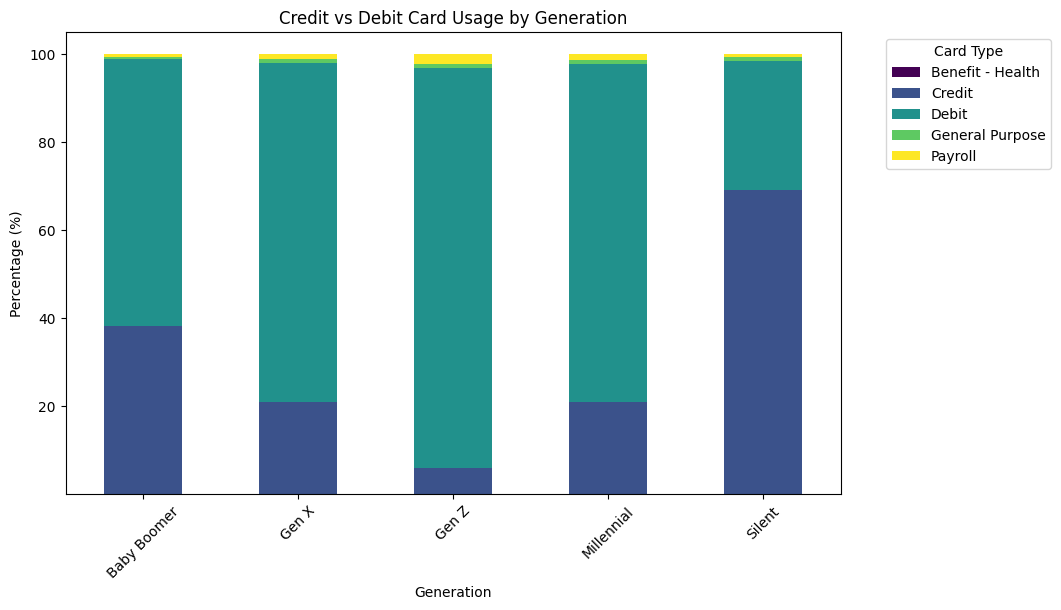

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분석 대상 데이터 필터링 (세대와 카드 종류 정보가 있는 것만)
analysis_df = df[df['CARD_HOLDER_GENERATION'].notnull() & df['CARD_TYPE'].notnull()].copy()

# 2. 세대별 카드 종류 비중 계산 (Crosstab 활용)
# normalize='index'를 쓰면 각 세대 내에서 카드 종류별 점유율(%)이 나옵니다.
gen_card_pivot = pd.crosstab(analysis_df['CARD_HOLDER_GENERATION'], 
                             analysis_df['CARD_TYPE'], 
                             normalize='index') * 100

print("--- 세대별 카드 종류 이용 비중 (%) ---")
print(gen_card_pivot.sort_index())

# 3. 결과 시각화 (Stacked Bar Chart)
gen_card_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Credit vs Debit Card Usage by Generation')
plt.ylabel('Percentage (%)')
plt.xlabel('Generation')
plt.legend(title='Card Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

print("--- 세대 정보(Generation) 결측치 혼재 여부 검사 시작 ---")

# 1. ACCOUNT_ID별로 GENERATION 컬럼의 전체 행 수(size)와 실제 값이 있는 행 수(count) 계산
# 400만 건 기준 약 5~10초 내외 소요
gen_stats = df.groupby('ACCOUNT_ID')['CARD_HOLDER_GENERATION'].agg(['size', 'count'])

# 2. 혼재된 조건 필터링
# 조건: 값이 하나라도 있고(count > 0), 전체 행 수보다는 적은(count < size) 경우
mixed_gen_mask = (gen_stats['count'] > 0) & (gen_stats['count'] < gen_stats['size'])
mixed_gen_customers = gen_stats[mixed_gen_mask]

# 3. 결과 출력
total_mixed = len(mixed_gen_customers)
print(f"결측치가 혼재된(일부만 비어있는) 고객 수: {total_mixed:,}명")

if total_mixed > 0:
    sample_ids = mixed_gen_customers.index[:5].tolist()
    print(f"예시 ACCOUNT_ID: {sample_ids}")
    
    # 예시 고객 데이터 직접 확인
    print(f"\n[샘플 고객 {sample_ids[0]}의 데이터 상태]")
    display(df[df['ACCOUNT_ID'] == sample_ids[0]][['ACCOUNT_ID', 'CARD_HOLDER_GENERATION']].head(10))
else:
    print("모든 고객이 '세대 정보가 다 있거나' 혹은 '아예 없거나' 둘 중 하나입니다.")

--- 세대 정보(Generation) 결측치 혼재 여부 검사 시작 ---
결측치가 혼재된(일부만 비어있는) 고객 수: 0명
모든 고객이 '세대 정보가 다 있거나' 혹은 '아예 없거나' 둘 중 하나입니다.


In [ ]:
import pandas as pd

# 1. 조건 설정: Benefit - Health 카드이면서 세대 정보가 결측치(NaN)인 행 추출
# (문자열 대소문자나 공백에 대비해 strip()과 lower()를 섞는 것이 안전합니다)
condition = (df['CARD_TYPE'].str.contains('Benefit', case=False, na=False)) & \
            (df['CARD_HOLDER_GENERATION'].isnull())

# 2. 해당되는 데이터 추출
benefit_health_missing = df[condition].copy()

# 3. 결과 출력
print(f"--- [Benefit - Health] 관련 결측치 현황 ---")
print(f"세대 정보가 없는 Benefit-Health 거래 건수: {len(benefit_health_missing):,}건")

if len(benefit_health_missing) > 0:
    # 중복 ID를 제외한 고유 고객 수 확인
    unique_customers = benefit_health_missing['ACCOUNT_ID'].nunique()
    print(f"해당되는 고유 고객(ACCOUNT_ID) 수: {unique_customers:,}명")
    
    # 이들이 주로 어디서 결제했는지(업종) 상위 5개 확인
    print("\n[이들의 주요 결제 업종 (Top 5)]")
    print(benefit_health_missing['MERCHANT_CATEGORY_LEVEL_1'].value_counts().head(5))
    
    # 샘플 ID 확인
    print(f"\n예시 ACCOUNT_ID: {benefit_health_missing['ACCOUNT_ID'].unique()[:5].tolist()}")
else:
    print("해당 조건에 맞는 결측치 데이터가 없습니다.")

--- [Benefit - Health] 관련 결측치 현황 ---
세대 정보가 없는 Benefit-Health 거래 건수: 82건
해당되는 고유 고객(ACCOUNT_ID) 수: 71명

[이들의 주요 결제 업종 (Top 5)]
MERCHANT_CATEGORY_LEVEL_1
Restaurants and Food Services    45
Consumer Services                 1
Retail                            1
Name: count, dtype: int64

예시 ACCOUNT_ID: ['A8993611', 'A1404962', 'A1761061', 'A8256638', 'A7346667']


--- [Benefit - Health] 카드 사용자 세대 분포 ---
Millennial: 40.00% (2명)
Silent: 20.00% (1명)
Baby Boomer: 20.00% (1명)
Gen X: 20.00% (1명)


C:\Users\한민영\AppData\Local\Temp\ipykernel_12940\2413785054.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gen_ratios.index, y=gen_ratios.values, palette='magma')


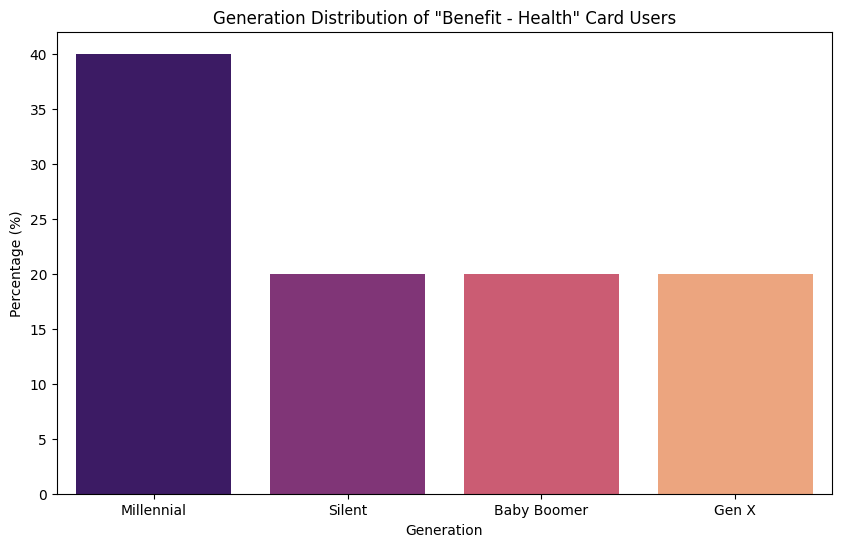

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 'Benefit - Health' 카드 사용자만 필터링 (세대 정보가 있는 것만)
benefit_users = df[
    (df['CARD_TYPE'].str.contains('Benefit', case=False, na=False)) & 
    (df['CARD_HOLDER_GENERATION'].notnull())
].copy()

# 2. 세대별 분포 계산 (인원수 및 비율)
gen_counts = benefit_users.groupby('ACCOUNT_ID')['CARD_HOLDER_GENERATION'].first().value_counts()
gen_ratios = benefit_users.groupby('ACCOUNT_ID')['CARD_HOLDER_GENERATION'].first().value_counts(normalize=True) * 100

print("--- [Benefit - Health] 카드 사용자 세대 분포 ---")
for gen, ratio in gen_ratios.items():
    print(f"{gen}: {ratio:.2f}% ({gen_counts[gen]:,}명)")

# 3. 시각화 (Pie Chart 또는 Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=gen_ratios.index, y=gen_ratios.values, palette='magma')
plt.title('Generation Distribution of "Benefit - Health" Card Users')
plt.ylabel('Percentage (%)')
plt.xlabel('Generation')
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

# 1. 분석용 샘플링 (400만 건 전체는 너무 오래 걸리므로 20만 건만 샘플링)
# 거주지 정보가 있는 데이터만 대상으로 합니다.
sample_df = df[df['CARD_HOLDER_STATE'].notnull()].sample(n=200000, random_state=42).copy()

# 2. 비교 대상 컬럼들
target = 'CARD_HOLDER_STATE'
candidates = [
    'MERCHANT_CITY', 'MERCHANT_STATE', 'MERCHANT_CATEGORY_LEVEL_1', 
    'CARD_TYPE', 'CARD_PRESENT_INDICATOR', 'txn_hour'
]

# 3. 범주형 데이터 인코딩 및 상호 정보량(Mutual Information) 계산
# MI Score가 높을수록 두 변수 간의 연관성이 높음을 의미합니다.
results = {}

for col in candidates:
    # 결측치는 'Unknown'으로 임시 대체
    s_col = sample_df[col].astype(str).fillna('Unknown')
    s_target = sample_df[target].astype(str)
    
    # Mutual Information 계산
    score = mutual_info_score(s_col, s_target)
    results[col] = score

# 4. 결과 정리 및 출력
relation_df = pd.DataFrame.from_dict(results, orient='index', columns=['Association_Score'])
relation_df = relation_df.sort_values(by='Association_Score', ascending=False)

print("--- [거주 지역(City)과 연관성이 높은 컬럼 순위] ---")
print(relation_df)

# 5. 추가 분석: 단순 일치율(Match Rate) 확인
match_rate = (sample_df['CARD_HOLDER_CITY'] == sample_df['MERCHANT_CITY']).mean() * 100
print(f"\n* 참고: 가맹점 도시와 거주지 도시가 단순 일치할 확률: {match_rate:.2f}%")

--- [거주 지역(City)과 연관성이 높은 컬럼 순위] ---
                           Association_Score
MERCHANT_STATE                      2.138356
MERCHANT_CITY                       2.104675
CARD_TYPE                           0.054134
txn_hour                            0.037183
CARD_PRESENT_INDICATOR              0.025443
MERCHANT_CATEGORY_LEVEL_1           0.008475

* 참고: 가맹점 도시와 거주지 도시가 단순 일치할 확률: 33.09%


In [10]:
import pandas as pd

# 1. TRANSACTION_DATE를 판다스 datetime 형식으로 변환
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])

# 2. 트렌드 분석을 위한 파생 변수 추출 (월, 요일, 시간)
df['MONTH'] = df['TRANSACTION_DATE'].dt.month
df['DAY_OF_WEEK'] = df['TRANSACTION_DATE'].dt.day_name()
df['HOUR'] = df['TRANSACTION_DATE'].dt.hour

# 3. 월별 총 결제액 및 거래 건수 트렌드 요약 확인
monthly_trend = df.groupby('MONTH').agg(
    TOTAL_SPEND=('GROSS_TRANSACTION_AMOUNT', 'sum'),
    TRANSACTION_COUNT=('TRANSACTION_ID', 'count')
).reset_index()

print("월별 결제 트렌드 요약:")
print(monthly_trend)

월별 결제 트렌드 요약:
   MONTH  TOTAL_SPEND  TRANSACTION_COUNT
0      1   9399310.91             717398
1      2   9975729.58             755269
2      3  11594218.25             853402
3      4  10935226.24             823844
4      5  11398012.10             845009
5      6  10699656.45             782713


✅ 시차 보정 완료! 'LOCAL_HOUR' 변수가 생성되었습니다.


C:\Users\한민영\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\한민영\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\한민영\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\한민영\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\한민영\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HA

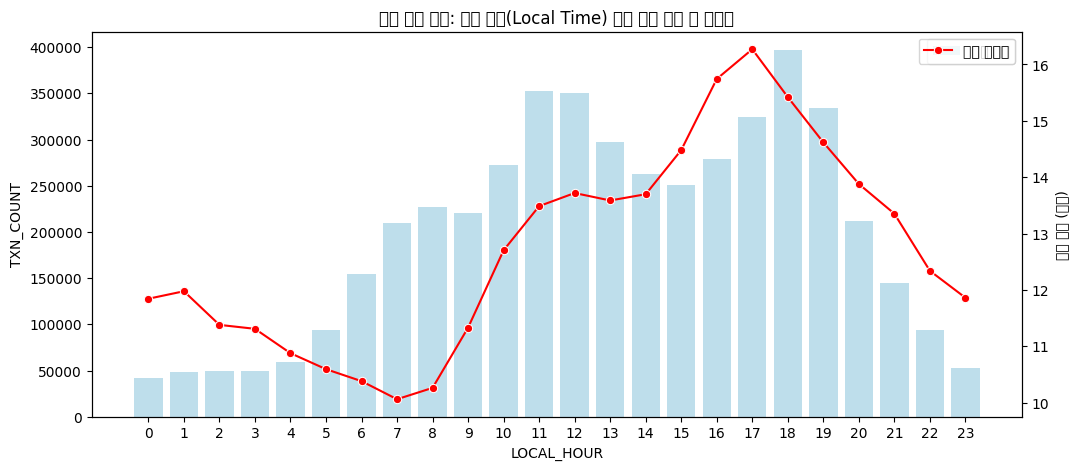


[시차 보정 후 진짜 데이터]
점심(11~14시) -> 평균 객단가: 13.62$ / 총 결제 건수: 1,263,089건
저녁(17~20시) -> 평균 객단가: 15.05$ / 총 결제 건수: 1,268,237건


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 미국 주(State)별 UTC 오프셋 딕셔너리 생성
# 동부(EST -5), 중부(CST -6), 산악(MST -7), 태평양(PST -8), 알래스카(-9), 하와이(-10)
timezone_offsets = {
    'EST': ['CT', 'DE', 'FL', 'GA', 'IN', 'ME', 'MD', 'MA', 'MI', 'NH', 'NJ', 'NY', 'NC', 'OH', 'PA', 'RI', 'SC', 'VT', 'VA', 'WV', 'DC'],
    'CST': ['AL', 'AR', 'IL', 'IA', 'KS', 'KY', 'LA', 'MN', 'MS', 'MO', 'NE', 'ND', 'OK', 'SD', 'TN', 'TX', 'WI'],
    'MST': ['AZ', 'CO', 'ID', 'MT', 'NM', 'UT', 'WY'],
    'PST': ['CA', 'NV', 'OR', 'WA'],
    'AKST': ['AK'],
    'HST': ['HI']
}

# 딕셔너리를 State: Offset 형태로 쫙 풀어주기
offset_map = {}
for state in timezone_offsets['EST']: offset_map[state] = -5
for state in timezone_offsets['CST']: offset_map[state] = -6
for state in timezone_offsets['MST']: offset_map[state] = -7
for state in timezone_offsets['PST']: offset_map[state] = -8
for state in timezone_offsets['AKST']: offset_map[state] = -9
for state in timezone_offsets['HST']: offset_map[state] = -10

# 2. 오프셋 적용하여 현지 시간(LOCAL_HOUR) 계산
# State가 Unknown이거나 군부대(AP, AE)인 경우, 미국 인구가 가장 많은 동부(-5) 기준으로 임의 맵핑합니다.
df['UTC_OFFSET'] = df['TRANSACTION_STATE'].map(offset_map).fillna(-5)

# (UTC 시간 + 오프셋) % 24 를 하면 음수가 나와도 0~23시의 정상적인 시간으로 돌아옵니다.
df['LOCAL_HOUR'] = (df['HOUR'] + df['UTC_OFFSET']) % 24
df['LOCAL_HOUR'] = df['LOCAL_HOUR'].astype(int)

print("✅ 시차 보정 완료! 'LOCAL_HOUR' 변수가 생성되었습니다.")

# ==========================================
# 3. 보정된 로컬 시간 기준으로 다시 그래프 그리기
# ==========================================
local_hourly_spend = df.groupby('LOCAL_HOUR').agg(
    AVG_SPEND=('GROSS_TRANSACTION_AMOUNT', 'mean'),
    TXN_COUNT=('TRANSACTION_ID', 'count')
).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=local_hourly_spend, x='LOCAL_HOUR', y='TXN_COUNT', color='skyblue', alpha=0.6, label='결제 건수')
ax2 = plt.twinx()
sns.lineplot(data=local_hourly_spend, x='LOCAL_HOUR', y='AVG_SPEND', color='red', marker='o', ax=ax2, label='평균 객단가')
plt.title('시차 보정 완료: 현지 시간(Local Time) 기준 결제 건수 및 객단가')
plt.xlabel('현지 시간 (Hour)')
plt.ylabel('결제 건수')
ax2.set_ylabel('평균 금액 (달러)')
plt.show()

# 다시 점심 vs 저녁 비교
lunch_local = local_hourly_spend[local_hourly_spend['LOCAL_HOUR'].between(11, 14)]
dinner_local = local_hourly_spend[local_hourly_spend['LOCAL_HOUR'].between(17, 20)]

print(f"\n[시차 보정 후 진짜 데이터]")
print(f"점심(11~14시) -> 평균 객단가: {lunch_local['AVG_SPEND'].mean():.2f}$ / 총 결제 건수: {lunch_local['TXN_COUNT'].sum():,}건")
print(f"저녁(17~20시) -> 평균 객단가: {dinner_local['AVG_SPEND'].mean():.2f}$ / 총 결제 건수: {dinner_local['TXN_COUNT'].sum():,}건")

In [15]:
# 1. 퇴근 이후(19-24시) + 오프라인(Card Present) 조건 결합
# 'CARD_PRESENT_INDICATOR' 열 이름을 확인해 주세요 (보통 이 이름입니다)
refined_home_df = df[
    (df['LOCAL_HOUR'].between(20, 23)) & 
    (df['CARD_PRESENT_INDICATOR'] == 'Card Present')
].copy()

# 2. 거주 주(State)와 결제 주(State) 정보가 있는 데이터만 추출
valid_refined = refined_home_df.dropna(subset=['CARD_HOLDER_STATE', 'MERCHANT_STATE'])

# 3. 일치율 계산
refined_match_rate = (valid_refined['CARD_HOLDER_STATE'] == valid_refined['MERCHANT_STATE']).mean() * 100

print(f"--- [초정밀 거주지 일치율 검증] ---")
print(f"분석 조건: 현지 20-24시 & 오프라인 결제 건")
print(f"분석 건수: {len(valid_refined):,}건")
print(f"동일 주(State) 내 결제 비율: {refined_match_rate:.2f}%")

--- [초정밀 거주지 일치율 검증] ---
분석 조건: 현지 20-24시 & 오프라인 결제 건
분석 건수: 384,425건
동일 주(State) 내 결제 비율: 78.43%


In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# 1. 분석에 사용할 피처 리스트 재정의
features = [
    'MERCHANT_STATE', 'MERCHANT_CITY', 'LOCAL_HOUR', 
    'DAY_OF_WEEK', 'MONTH', 'GROSS_TRANSACTION_AMOUNT', 
    'CARD_PRESENT_INDICATOR', 'TRANSACTION_TYPE', 
    'MERCHANT_CATEGORY_LEVEL_1', 'CARD_TYPE', 
    'CARD_HOLDER_TOTAL_SPEND', 'CARD_HOLDER_VINTAGE', 
    'SHOPPER_CLASSIFICATION'
]

# 2. 문자열(Object/Str) 타입 열들만 자동으로 찾아 인코딩 수행
le = LabelEncoder()

# 원본 데이터를 보존하려면 copy()를 사용하세요
df_encoded = df.copy()

for col in features:
    # 데이터 타입이 문자열(object)인 경우에만 인코딩 진행
    if df_encoded[col].dtype == 'object' or df_encoded[col].dtype == 'str':
        # 결측치를 'Unknown'으로 채우고 숫자로 변환
        df_encoded[col] = le.fit_transform(df_encoded[col].fillna('Unknown').astype(str))

# 3. 타겟 변수(정답) 인코딩 (CARD_HOLDER_STATE)
target_le = LabelEncoder()
# 정답이 있는 행들만 필터링
train_mask = df_encoded['CARD_HOLDER_STATE'].notnull()
y_encoded = target_le.fit_transform(df_encoded.loc[train_mask, 'CARD_HOLDER_STATE'].astype(str))

# 4. 모델 학습용 X 데이터 설정 (인코딩된 데이터 사용)
X_train = df_encoded.loc[train_mask, features]

# 5. 모델 학습 (이제 에러가 발생하지 않습니다)
dt_temp = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_temp.fit(X_train, y_encoded)

# 6. 피처 중요도 확인
importances = pd.DataFrame({
    'feature': features,
    'importance': dt_temp.feature_importances_
}).sort_values(by='importance', ascending=False)

print("--- [피처 중요도 분석 결과] ---")
print(importances)

--- [피처 중요도 분석 결과] ---
                      feature  importance
0              MERCHANT_STATE    0.908045
1               MERCHANT_CITY    0.061089
7            TRANSACTION_TYPE    0.011250
6      CARD_PRESENT_INDICATOR    0.006946
5    GROSS_TRANSACTION_AMOUNT    0.004939
2                  LOCAL_HOUR    0.003828
8   MERCHANT_CATEGORY_LEVEL_1    0.002287
9                   CARD_TYPE    0.001185
11        CARD_HOLDER_VINTAGE    0.000244
10    CARD_HOLDER_TOTAL_SPEND    0.000119
4                       MONTH    0.000045
3                 DAY_OF_WEEK    0.000014
12     SHOPPER_CLASSIFICATION    0.000007


In [31]:
# 1. 유의미한 피처만 선별 (중요도 0.001 이상)
final_features = [
    'MERCHANT_STATE', 'MERCHANT_CITY', 'TRANSACTION_TYPE', 
    'CARD_PRESENT_INDICATOR', 'GROSS_TRANSACTION_AMOUNT', 
    'LOCAL_HOUR', 'MERCHANT_CATEGORY_LEVEL_1', 'CARD_TYPE'
]

# 2. 예측 대상 데이터 준비 (CARD_HOLDER_STATE가 NaN인 행)
predict_mask = df_encoded['CARD_HOLDER_STATE'].isnull()
X_predict = df_encoded.loc[predict_mask, final_features]

# 3. 예측 수행
# 학습된 dt_temp 모델을 사용 (단, features 리스트가 위 final_features와 일치해야 함)
# 만약 위에서 전체 features로 학습했다면 아래와 같이 다시 학습하거나 X_predict를 맞춤
X_train_final = df_encoded.loc[train_mask, final_features]
final_model = DecisionTreeClassifier(max_depth=10, random_state=42)
final_model.fit(X_train_final, y_encoded)

y_pred_numeric = final_model.predict(X_predict)



In [37]:
# 1. 학습 데이터(정답이 있는 데이터)에 대한 예측 확률 계산
y_train_proba = final_model.predict_proba(X_train_final)
train_max_probas = y_train_proba.max(axis=1)

# 2. 확신 점수가 0.9 이상인 인덱스만 추출
high_conf_train_mask = (train_max_probas >= 0.5) # 예시로 0.9 설정 가능

# 3. 고확신 데이터에 대한 실제 정답 vs 예측값 비교
y_train_true = y_encoded[high_conf_train_mask]
y_train_pred = final_model.predict(X_train_final)[high_conf_train_mask]

from sklearn.metrics import accuracy_score
high_conf_accuracy = accuracy_score(y_train_true, y_train_pred)

print(f"--- [고확신 데이터(Confidence >= 0.9) 내부 정확도] ---")
print(f"대상 건수: {len(y_train_true):,}건")
print(f"정확도(Accuracy): {high_conf_accuracy:.4f}")

--- [고확신 데이터(Confidence >= 0.9) 내부 정확도] ---
대상 건수: 3,598,002건
정확도(Accuracy): 0.8933


In [38]:
# 1. 기존 데이터(Original)와 예측으로 채워진 데이터(Predicted)의 주별 분포 비교
original_dist = df.loc[train_mask, 'CARD_HOLDER_STATE'].value_counts(normalize=True).head(10)
predicted_dist = df.loc[predict_mask & ~df.index.isin(rows_to_reset), 'CARD_HOLDER_STATE'].value_counts(normalize=True).head(10)

comparison_df = pd.DataFrame({
    'Original_Ratio': original_dist,
    'Predicted_Ratio': predicted_dist
})

print("--- [기존 vs 예측 데이터 지역 분포 비교] ---")
print(comparison_df)

# 2. 두 분포의 차이가 크지 않다면 모델이 편향 없이 잘 채운 것입니다.

--- [기존 vs 예측 데이터 지역 분포 비교] ---
                   Original_Ratio  Predicted_Ratio
CARD_HOLDER_STATE                                 
CA                       0.061633         0.063931
FL                       0.073055         0.087689
IN                       0.039492         0.065443
MI                       0.057830         0.079266
MN                       0.039247         0.067603
NC                       0.043896              NaN
OH                       0.086696         0.115119
TN                       0.038703         0.070842
TX                       0.087771         0.093521
UT                            NaN         0.058963
VA                       0.038458         0.066523


In [33]:
from sklearn.metrics import accuracy_score, classification_report

# 1. 정답이 원래 있었던 데이터만 다시 추출
X_orig = df_encoded.loc[train_mask, final_features]
y_orig = y_encoded  # 실제 정답(숫자)

# 2. 이미 학습된 final_model로 이 데이터들을 다시 예측해봄
y_orig_pred = final_model.predict(X_orig)

# 3. 정확도 계산
orig_accuracy = accuracy_score(y_orig, y_orig_pred)

print(f"--- [기존 데이터 기준 모델 자가 진단] ---")
print(f"정확도(Accuracy): {orig_accuracy:.4f}")
print("\n* 이 점수가 0.85 이상이라면, 채워진 13만 건도 상당히 신뢰할 수 있습니다.")

--- [기존 데이터 기준 모델 자가 진단] ---
정확도(Accuracy): 0.7243

* 이 점수가 0.85 이상이라면, 채워진 13만 건도 상당히 신뢰할 수 있습니다.


In [34]:
# 1. 모델이 예측할 때의 '확신 점수(Probability)' 계산
# 각 행마다 "내가 이 주로 예측할 확률이 몇 %인가"를 알려줍니다.
y_pred_proba = final_model.predict_proba(X_predict)
max_probas = y_pred_proba.max(axis=1) # 가장 높은 확률값만 추출

# 2. 확신이 90% 이상인 것만 남기고, 나머지는 다시 NaN으로 되돌리기
# 모델이 "긴가민가" 했던(확률 낮은) 데이터는 차라리 비워두는 게 분석 신뢰도에 좋습니다.
threshold = 0.90
low_confidence_mask = (max_probas < threshold)

# 예측 데이터 중 확신이 낮은 행들의 거주지를 다시 결측치(NaN)로 변경
# predict_mask는 아까 13만 건을 찾았던 마스크입니다.
rows_to_reset = df.loc[predict_mask].index[low_confidence_mask]
df.loc[rows_to_reset, 'CARD_HOLDER_STATE'] = np.nan

print(f"--- [데이터 정밀화 결과] ---")
print(f"전체 예측 건수: {len(X_predict):,}건")
print(f"확신 부족으로 삭제된 건수: {len(rows_to_reset):,}건")
print(f"최종 신뢰 데이터 건수: {len(X_predict) - len(rows_to_reset):,}건")

--- [데이터 정밀화 결과] ---
전체 예측 건수: 15,934건
확신 부족으로 삭제된 건수: 11,304건
최종 신뢰 데이터 건수: 4,630건


--- [확신 부족 데이터의 특징 분석] ---
CARD_PRESENT_INDICATOR
2    0.603592
1    0.360669
0    0.035740
Name: proportion, dtype: float64


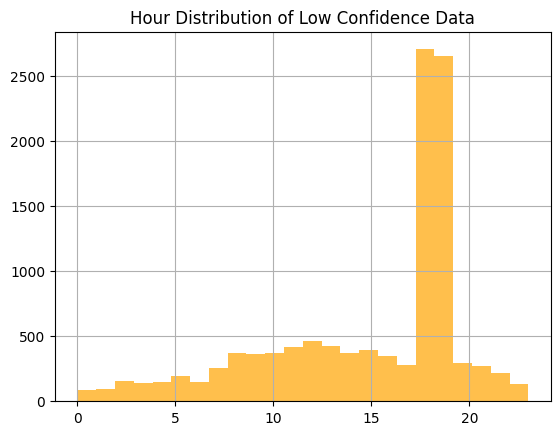

In [35]:
# 1. 확신이 낮아 삭제된 데이터들만 추출
uncertain_df = df_encoded.loc[rows_to_reset].copy()

# 2. 삭제된 데이터들의 특징 확인 (예: 온라인 결제 비중이 높은가?)
print("--- [확신 부족 데이터의 특징 분석] ---")
print(uncertain_df['CARD_PRESENT_INDICATOR'].value_counts(normalize=True))

# 3. 삭제된 데이터들의 시간대 분포 확인
import matplotlib.pyplot as plt
uncertain_df['LOCAL_HOUR'].hist(bins=24, color='orange', alpha=0.7)
plt.title('Hour Distribution of Low Confidence Data')
plt.show()

In [36]:
# 1. 확신이 90% 이상이었던 최종 신뢰 데이터의 주별 분포 확인
final_trusted_df = df.loc[df['CARD_HOLDER_STATE'].notnull() & ~df.index.isin(rows_to_reset)]

print("--- [최종 신뢰 데이터 거주지 TOP 5] ---")
print(final_trusted_df['CARD_HOLDER_STATE'].value_counts().head())

# 2. (선택) 원래 결측치였으나 성공적으로 채워진 주들의 비율
added_states_dist = final_trusted_df.loc[predict_mask, 'CARD_HOLDER_STATE'].value_counts()
print("\n--- [결측치에서 채워진 주 분포] ---")
print(added_states_dist.head())

--- [최종 신뢰 데이터 거주지 TOP 5] ---
CARD_HOLDER_STATE
TX    418374
OH    413352
FL    348273
CA    293773
MI    275736
Name: count, dtype: int64

--- [결측치에서 채워진 주 분포] ---
CARD_HOLDER_STATE
OH    533
TX    433
FL    406
MI    367
TN    328
Name: count, dtype: int64


In [ ]:
# 4. 숫자 라벨을 실제 주(State) 이름으로 역변환
predicted_states = target_le.inverse_transform(y_pred_numeric)

# 5. 원본 데이터프레임의 결측치 채우기
df.loc[predict_mask, 'CARD_HOLDER_STATE'] = predicted_states

print(f"✅ 총 {len(predicted_states):,}건의 거주지 결측치를 성공적으로 채웠습니다.")
print(df['CARD_HOLDER_STATE'].value_counts().head())

In [32]:
df.isnull().sum()

ACCOUNT_ID                                    132703
CARD_ID                                            0
TRANSACTION_ID                                     0
GROSS_TRANSACTION_AMOUNT                           0
TRANSACTION_DATE                                   0
TRANSACTION_TYPE                                   1
TRANSACTION_STATE                             121664
TRANSACTION_CITY                              143825
MERCHANT_STATE                                583358
MERCHANT_CITY                                 702539
MERCHANT_CATEGORY_LEVEL_1                    1293772
MERCHANT_CATEGORY_LEVEL_2                    1293772
MERCHANT_CATEGORY_LEVEL_3                    1293982
TRANSACTION_DESCRIPTION                         5463
CARD_TYPE                                          0
CARD_HOLDER_STATE                                  0
CARD_HOLDER_CITY                               15934
CARD_HOLDER_GENERATION                         57808
CARD_HOLDER_TOTAL_TRANSACTION_COUNT           